# Module 06: Transformer

## Introduction

The **transformer decoder block** is the building block of GPT-style
language models. Stack 12-96 of these blocks, and you get models like
GPT-2, GPT-3, or LLaMA.

In this module, we’ll combine everything we’ve built so far:

-   **Multi-head attention** from Module 05
-   **Feed-forward networks** (mini neural networks for each token)
-   **Layer normalization** (stabilizes training)
-   **Residual connections** (enables deep networks)

Each block performs two main operations:

1.  **Multi-head attention**: Tokens communicate with each other
2.  **Feed-forward network**: Each token is processed independently

### Decoder-Only vs Encoder-Decoder

This module implements **decoder-only** transformers (GPT-style). There
are two main transformer architectures:

| Architecture | Examples | Use Case | Attention |
|---------------------|-----------------|-----------------|------------------|
| Decoder-only | GPT, LLaMA, Claude | Text generation | Causal (can’t see future) |
| Encoder-Decoder | T5, BART, original Transformer | Translation, summarization | Bidirectional encoder + causal decoder |

We focus on decoder-only because it’s simpler and powers most modern
LLMs.

## Complete Model Architecture

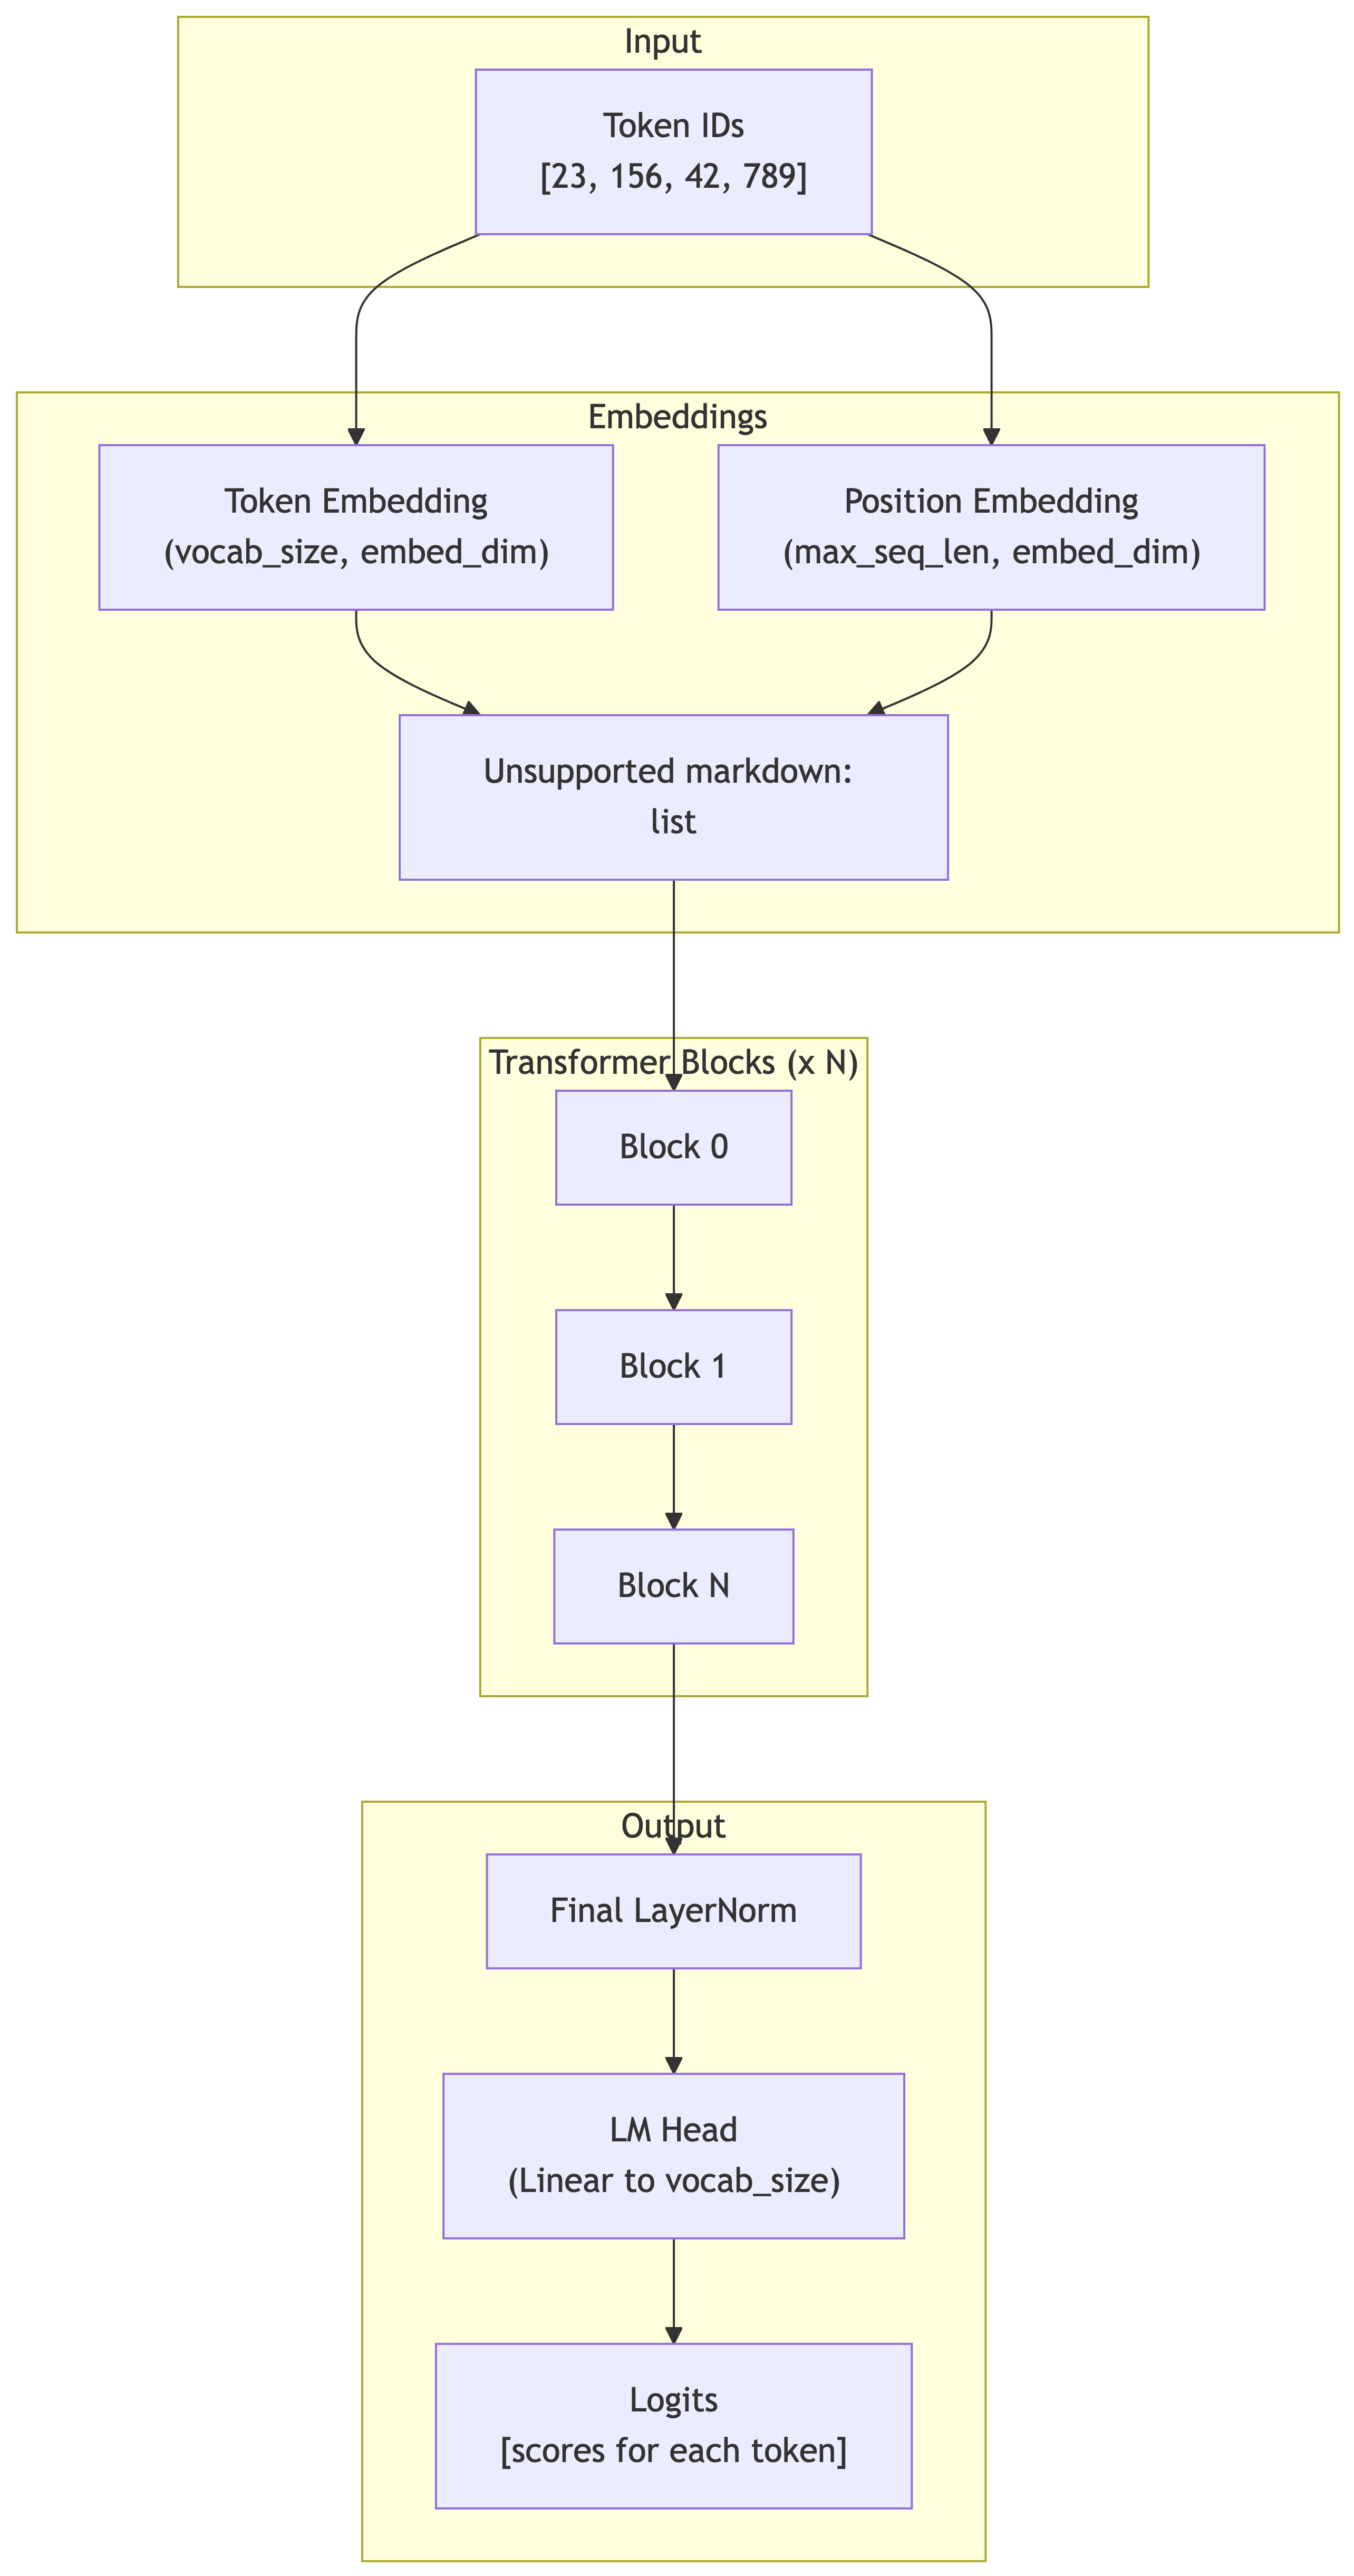

## Single Transformer Block (Pre-Norm)

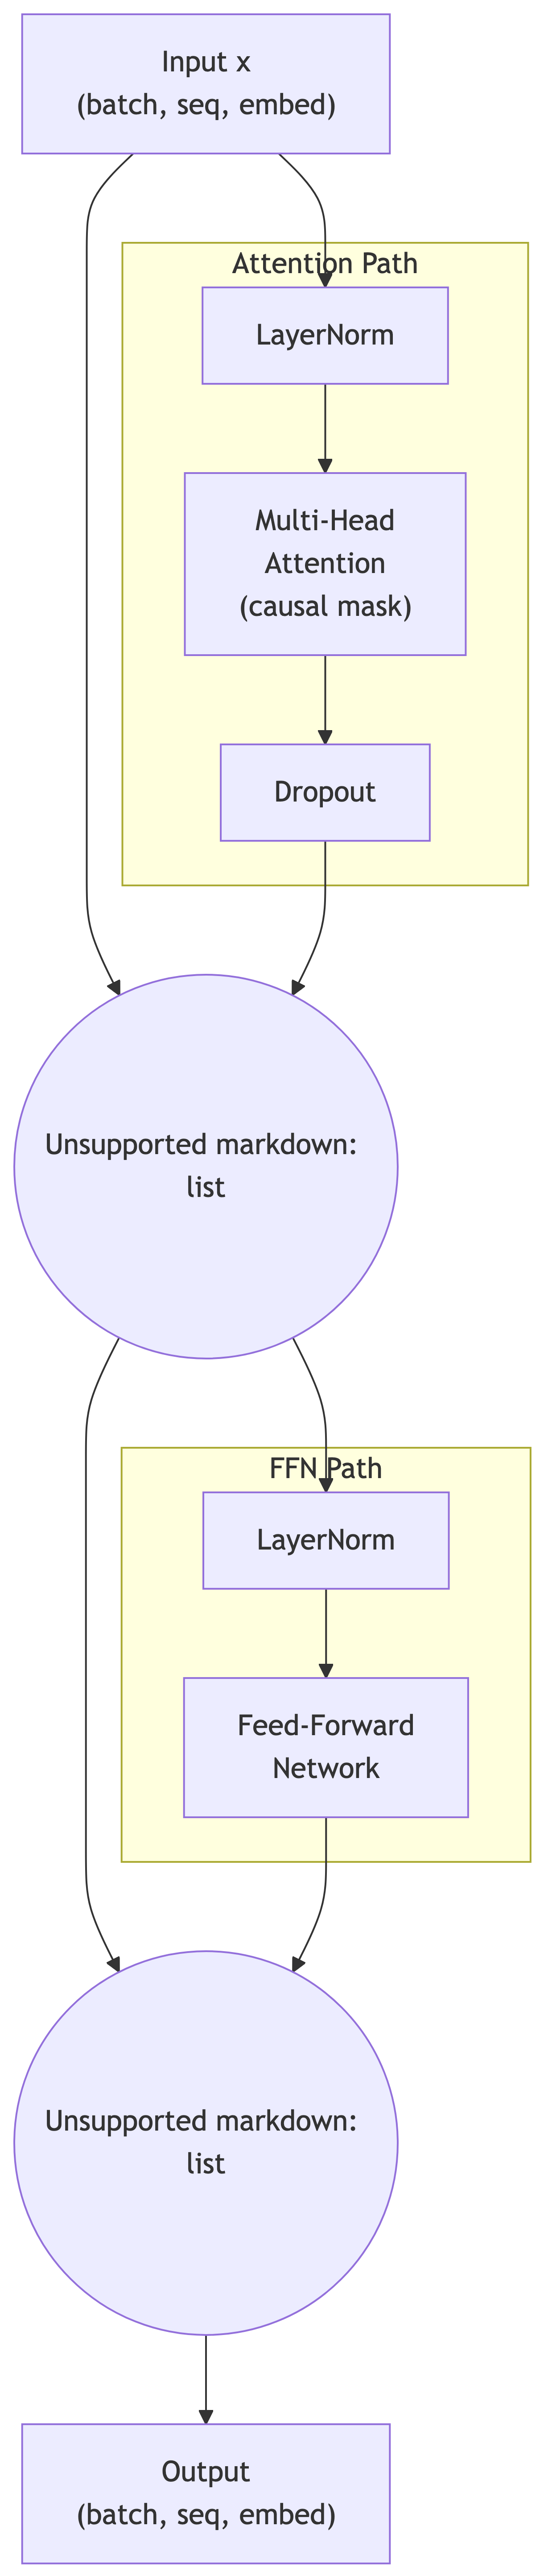

The key innovation is the **residual connections** (the + nodes).
Instead of `y = f(x)`, we compute `y = x + f(x)`. This:

-   Helps gradients flow through deep networks
-   Makes it easy to learn identity (just set `f(x) = 0`)
-   Enables training of 100+ layer networks

## The Components

### Layer Normalization

Normalizes activations across the embedding dimension:

$$\text{LayerNorm}(x) = \gamma \times \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

where $\mu$ and $\sigma^2$ are the mean and variance across the
embedding dimension, and $\gamma$, $\beta$ are learnable parameters.

Why it helps:

-   **Stabilizes activations**: Prevents values from exploding or
    vanishing
-   **Faster training**: More stable gradients
-   **Independent per token**: Each token normalized separately

### Feed-Forward Network (FFN)

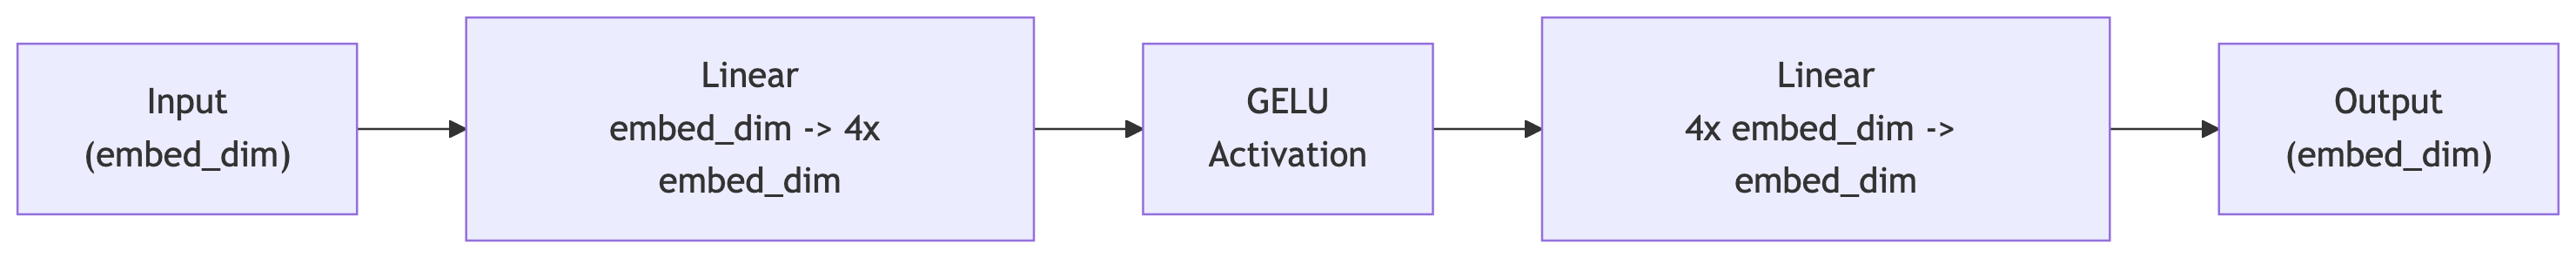

The FFN is a mini neural network applied to each token independently:

-   **4x expansion**: More capacity to learn complex transformations
-   **GELU activation**: Smoother than ReLU, better gradients
-   **Same for all tokens**: Unlike attention, no mixing between
    positions

### Pre-Norm vs Post-Norm

We use **Pre-Norm** (LayerNorm before attention/FFN) rather than
Post-Norm:

``` python
# Pre-Norm (GPT-2, LLaMA, modern LLMs)
x = x + Attention(LayerNorm(x))

# Post-Norm (original Transformer paper)
x = LayerNorm(x + Attention(x))
```

**Why Pre-Norm is preferred:**

1.  **Cleaner gradient path**: The residual connection bypasses
    normalization, so gradients flow directly
2.  **More stable training**: Especially important for deep networks
    (24+ layers)
3.  **Requires final LayerNorm**: Since the last block’s output isn’t
    normalized, we add a final LayerNorm before the output projection

Post-Norm can achieve slightly better final performance with careful
hyperparameter tuning, but Pre-Norm is more robust and easier to train.

## Code Walkthrough

Let’s build and explore transformer blocks:

In [1]:
import sys
import importlib.util
from pathlib import Path

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

PyTorch version: 2.9.1
Device: mps

### GELU Activation

GPT uses GELU instead of ReLU. Let’s see why:

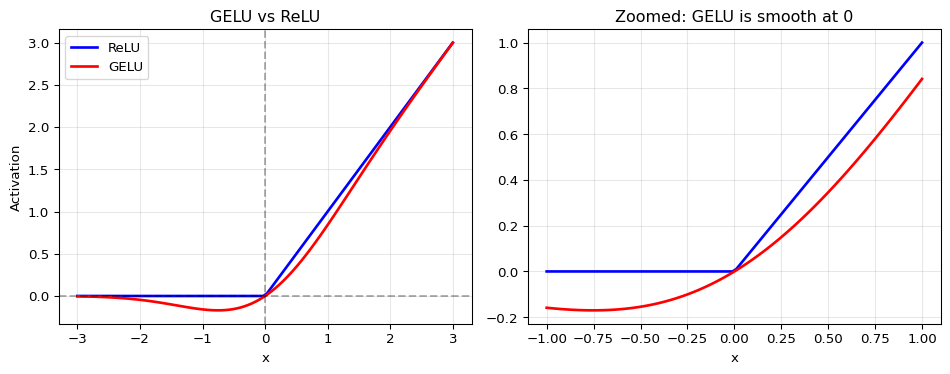

Key difference: GELU is smooth everywhere!
ReLU has a sharp corner at x=0, which can cause gradient issues.

In [2]:
import torch.nn.functional as F

x = torch.linspace(-3, 3, 100)
gelu_out = F.gelu(x)
relu_out = torch.relu(x)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(x.numpy(), relu_out.numpy(), 'b-', label='ReLU', linewidth=2)
plt.plot(x.numpy(), gelu_out.numpy(), 'r-', label='GELU', linewidth=2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.xlabel('x')
plt.ylabel('Activation')
plt.legend()
plt.title('GELU vs ReLU')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
x_zoom = torch.linspace(-1, 1, 100)
plt.plot(x_zoom.numpy(), torch.relu(x_zoom).numpy(), 'b-', label='ReLU', linewidth=2)
plt.plot(x_zoom.numpy(), F.gelu(x_zoom).numpy(), 'r-', label='GELU', linewidth=2)
plt.xlabel('x')
plt.title('Zoomed: GELU is smooth at 0')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key difference: GELU is smooth everywhere!")
print("ReLU has a sharp corner at x=0, which can cause gradient issues.")

**GELU formula**: $\text{GELU}(x) = x \cdot \Phi(x)$ where $\Phi$ is the
standard normal CDF.

Approximation used in practice:
$0.5x(1 + \tanh(\sqrt{2/\pi}(x + 0.044715x^3)))$

**Activation function choices in modern LLMs:**

| Model          | Activation | Notes                             |
|----------------|------------|-----------------------------------|
| GPT-2, BERT    | GELU       | Smooth, good gradients            |
| LLaMA, Mistral | SwiGLU     | Gated variant, better performance |
| GPT-3          | GELU       | Same as GPT-2                     |

**SwiGLU** (used in LLaMA) is a gated linear unit:
$\text{SwiGLU}(x) = \text{Swish}(xW_1) \otimes xW_2$. It requires an
extra linear layer but often improves performance. Our implementation
uses standard GELU to match GPT-2.

### Layer Normalization Demo

In [3]:
# Manual LayerNorm demonstration
x = torch.tensor([[2.0, 4.0, 6.0, 8.0]])

mean = x.mean(dim=-1, keepdim=True)
var = x.var(dim=-1, unbiased=False, keepdim=True)
normalized = (x - mean) / torch.sqrt(var + 1e-5)

print("Manual LayerNorm:")
print(f"  Input: {x.numpy().tolist()}")
print(f"  Mean: {mean.item():.2f}")
print(f"  Variance: {var.item():.2f}")
print(f"  Normalized: {normalized.numpy().round(2).tolist()}")
print(f"  New mean: {normalized.mean().item():.4f}")
print(f"  New std: {normalized.std().item():.4f}")

Manual LayerNorm:
  Input: [[2.0, 4.0, 6.0, 8.0]]
  Mean: 5.00
  Variance: 5.00
  Normalized: [[-1.340000033378601, -0.44999998807907104, 0.44999998807907104, 1.340000033378601]]
  New mean: 0.0000
  New std: 1.1547

In [4]:
# PyTorch LayerNorm (with learnable gamma and beta)
ln = nn.LayerNorm(4)
pytorch_normalized = ln(x)

print(f"PyTorch LayerNorm output: {pytorch_normalized.detach().numpy().round(2).tolist()}")
print("(gamma and beta are learnable parameters)")

PyTorch LayerNorm output: [[-1.340000033378601, -0.44999998807907104, 0.44999998807907104, 1.340000033378601]]
(gamma and beta are learnable parameters)

### Residual Connections Demo

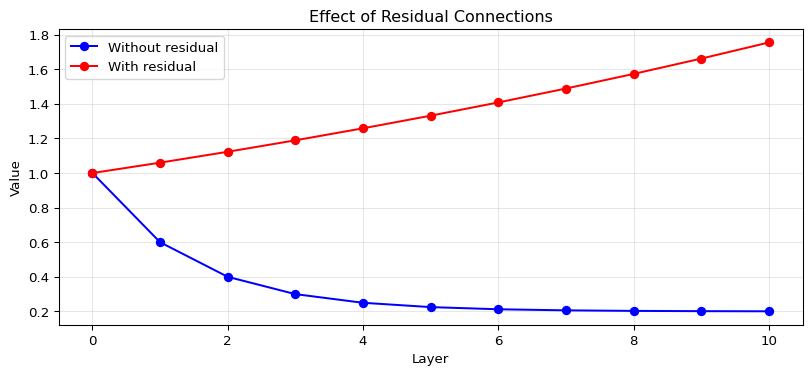

Without residual: value shrinks to 0.2008
With residual: value stays near 1.7547

In [5]:
# Demonstrate gradient flow with and without residuals
def simple_layer(x):
    """A simple transformation that shrinks values."""
    return x * 0.5 + 0.1

# Stack 10 layers WITHOUT residual
x = torch.tensor([1.0])
outputs_no_residual = [x.item()]
for _ in range(10):
    x = simple_layer(x)
    outputs_no_residual.append(x.item())

# Stack 10 layers WITH residual
x = torch.tensor([1.0])
outputs_with_residual = [x.item()]
for _ in range(10):
    x = x + simple_layer(x) * 0.1  # x + f(x)
    outputs_with_residual.append(x.item())

plt.figure(figsize=(10, 4))
plt.plot(outputs_no_residual, 'b-o', label='Without residual')
plt.plot(outputs_with_residual, 'r-o', label='With residual')
plt.xlabel('Layer')
plt.ylabel('Value')
plt.title('Effect of Residual Connections')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Without residual: value shrinks to {outputs_no_residual[-1]:.4f}")
print(f"With residual: value stays near {outputs_with_residual[-1]:.4f}")

### Weight Initialization

Proper initialization is critical for training deep networks. Our
implementation uses:

-   **Embeddings**: Normal distribution with std=0.02
-   **Linear layers in FFN**: Normal distribution with std=0.02, biases
    initialized to 0
-   **Attention projections**: Xavier uniform initialization

In [6]:
# Demonstrate the importance of initialization
import torch.nn as nn

# Bad initialization - too large
bad_linear = nn.Linear(768, 768)
nn.init.normal_(bad_linear.weight, std=1.0)  # Too large!

# Good initialization - small weights
good_linear = nn.Linear(768, 768)
nn.init.normal_(good_linear.weight, std=0.02)  # GPT-2 style

x = torch.randn(1, 10, 768)
bad_out = bad_linear(x)
good_out = good_linear(x)

print("Effect of initialization on output magnitude:")
print(f"  Bad init (std=1.0):  output std = {bad_out.std().item():.2f}")
print(f"  Good init (std=0.02): output std = {good_out.std().item():.2f}")
print("\nLarge outputs can cause exploding gradients and NaN losses!")

Effect of initialization on output magnitude:
  Bad init (std=1.0):  output std = 27.60
  Good init (std=0.02): output std = 0.56

Large outputs can cause exploding gradients and NaN losses!

**GPT-2’s initialization trick**: Scale the final projection in each
residual block by $1/\sqrt{2N}$ where N is the number of layers. This
keeps the variance stable as depth increases.

### Building a Transformer Block

In [7]:
from transformer import (
    FeedForward,
    TransformerBlock,
    GPTModel,
    create_gpt_tiny,
    create_gpt_small,
)

# Create a transformer block
embed_dim = 64
num_heads = 4
ff_dim = 256

block = TransformerBlock(
    embed_dim=embed_dim,
    num_heads=num_heads,
    ff_dim=ff_dim,
    dropout=0.0
)

print(f"Transformer Block:")
print(f"  Embed dim: {embed_dim}")
print(f"  Num heads: {num_heads}")
print(f"  Head dim: {embed_dim // num_heads}")
print(f"  FF dim: {ff_dim}")
print(f"\nTotal parameters: {sum(p.numel() for p in block.parameters()):,}")

Transformer Block:
  Embed dim: 64
  Num heads: 4
  Head dim: 16
  FF dim: 256

Total parameters: 49,984

In [8]:
# Forward pass
x = torch.randn(1, 8, embed_dim)  # batch=1, seq=8
output, attention = block(x, return_attention=True)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention shape: {attention.shape}")

Input shape: torch.Size([1, 8, 64])
Output shape: torch.Size([1, 8, 64])
Attention shape: torch.Size([1, 4, 8, 8])

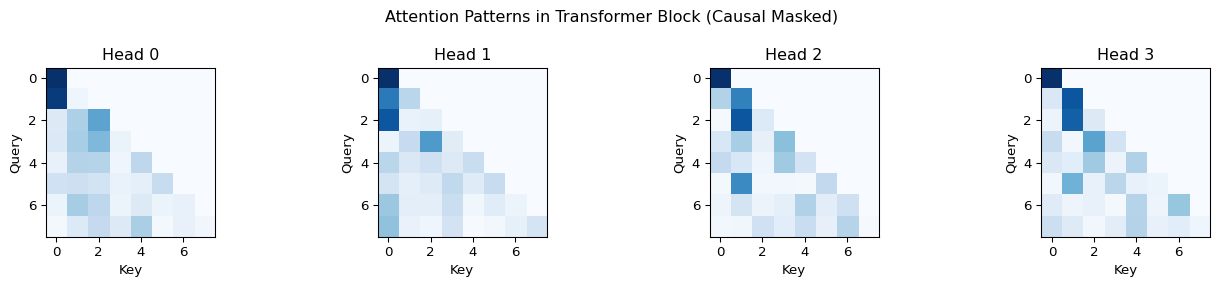

In [9]:
# Visualize attention patterns from the block
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

for head in range(4):
    ax = axes[head]
    w = attention[0, head].detach().numpy()
    ax.imshow(w, cmap='Blues', vmin=0, vmax=w.max())
    ax.set_title(f'Head {head}')
    ax.set_xlabel('Key')
    ax.set_ylabel('Query')

plt.suptitle('Attention Patterns in Transformer Block (Causal Masked)', fontsize=12)
plt.tight_layout()
plt.show()

### Complete GPT Model

In [10]:
# Create a tiny GPT model
model = create_gpt_tiny(vocab_size=1000)

print("GPT Tiny Model:")
print(f"  Vocab size: {model.vocab_size}")
print(f"  Embed dim: {model.embed_dim}")
print(f"  Num layers: {len(model.blocks)}")
print(f"  Max seq len: {model.max_seq_len}")
print(f"\nTotal parameters: {model.num_params:,}")

GPT Tiny Model:
  Vocab size: 1000
  Embed dim: 128
  Num layers: 4
  Max seq len: 256

Total parameters: 954,112

Parameter breakdown:
  token_embedding: 128,000 (13.4%)
  position_embedding: 32,768 (3.4%)
  transformer_blocks: 793,088 (83.1%)
  final_layer_norm: 256 (0.0%)
  total: 954,112 (100.0%)

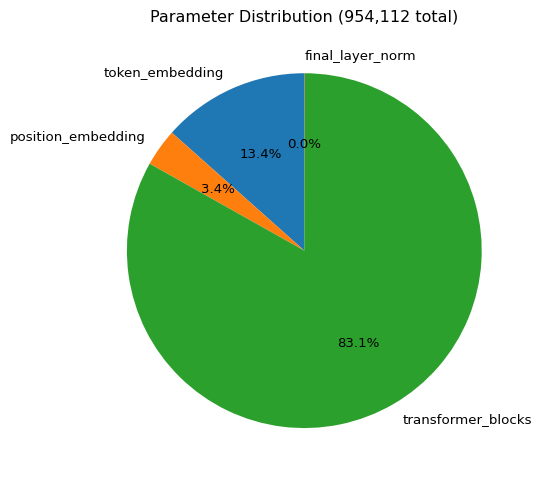

In [11]:
# Parameter breakdown
counts = model.count_parameters()

print("Parameter breakdown:")
for name, count in counts.items():
    if count > 0:
        pct = 100 * count / counts['total']
        print(f"  {name}: {count:,} ({pct:.1f}%)")

# Visualize
labels = [k for k, v in counts.items() if v > 0 and k != 'total']
sizes = [counts[k] for k in labels]

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title(f'Parameter Distribution ({model.num_params:,} total)')
plt.show()

In [12]:
# Forward pass
token_ids = torch.randint(0, 1000, (2, 32))  # batch=2, seq=32
logits = model(token_ids)

print(f"Input token IDs: {token_ids.shape}")
print(f"Output logits: {logits.shape}")
print(f"  (batch=2, seq=32, vocab=1000)")

# Get predictions
probs = torch.softmax(logits[0, -1], dim=-1)
top_5 = torch.topk(probs, 5)

print("\nTop 5 predicted next tokens (untrained, so random):")
for i, (idx, prob) in enumerate(zip(top_5.indices, top_5.values)):
    print(f"  {i+1}. Token {idx.item()}: {prob.item()*100:.2f}%")

Input token IDs: torch.Size([2, 32])
Output logits: torch.Size([2, 32, 1000])
  (batch=2, seq=32, vocab=1000)

Top 5 predicted next tokens (untrained, so random):
  1. Token 587: 0.22%
  2. Token 232: 0.22%
  3. Token 374: 0.20%
  4. Token 984: 0.19%
  5. Token 387: 0.18%

### Hidden States Through Layers

Number of hidden states: 5
  (1 after embedding + 4 after each block)

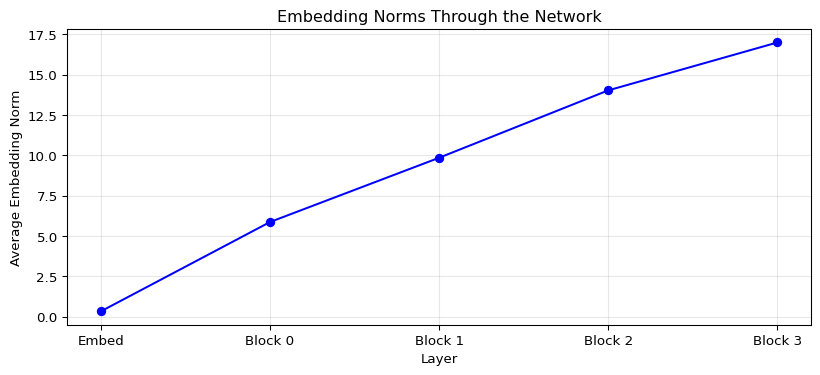

In [13]:
# Get hidden states from all layers
logits, hidden_states = model(token_ids, return_hidden_states=True)

print(f"Number of hidden states: {len(hidden_states)}")
print(f"  (1 after embedding + {len(model.blocks)} after each block)")

# Show how representations change through layers
norms = [h.norm(dim=-1).mean().item() for h in hidden_states]

plt.figure(figsize=(10, 4))
plt.plot(range(len(norms)), norms, 'b-o')
plt.xlabel('Layer')
plt.ylabel('Average Embedding Norm')
plt.title('Embedding Norms Through the Network')
plt.xticks(range(len(norms)), ['Embed'] + [f'Block {i}' for i in range(len(model.blocks))])
plt.grid(True, alpha=0.3)
plt.show()

### Weight Tying

GPT shares weights between token embedding and output projection:

In [14]:
# Check weight tying
print("Weight Tying:")
print(f"  Token embedding weight id: {id(model.token_embedding.weight)}")
print(f"  LM head weight id: {id(model.lm_head.weight)}")
print(f"  Are they the same object? {model.token_embedding.weight is model.lm_head.weight}")

# This saves parameters!
vocab_size = 1000
embed_dim = 128
saved_params = vocab_size * embed_dim
print(f"\nParameters saved by weight tying: {saved_params:,}")

Weight Tying:
  Token embedding weight id: 4633833104
  LM head weight id: 4633833104
  Are they the same object? True

Parameters saved by weight tying: 128,000

## Model Sizes Comparison

| Model        | Layers | Heads | Embed Dim | Params |
|--------------|--------|-------|-----------|--------|
| Tiny (ours)  | 4      | 4     | 128       | ~1M    |
| Small (ours) | 6      | 6     | 384       | ~10M   |
| GPT-2 Small  | 12     | 12    | 768       | 117M   |
| GPT-2 Medium | 24     | 16    | 1024      | 345M   |
| GPT-2 Large  | 36     | 20    | 1280      | 774M   |
| GPT-2 XL     | 48     | 25    | 1600      | 1.5B   |

### Parameter Counting Formulas

Understanding where parameters come from helps with model sizing:

**Per Transformer Block:**

-   Attention Q, K, V projections: $3 \times d \times d$ (where $d$ =
    embed_dim)
-   Attention output projection: $d \times d$
-   FFN first linear: $d \times 4d$
-   FFN second linear: $4d \times d$
-   LayerNorm (x2): $2 \times 2d$ (gamma and beta for each)

Total per block: $\approx 12d^2$ parameters

**Full Model:**

-   Token embedding: $V \times d$ (V = vocab size)
-   Position embedding: $L \times d$ (L = max sequence length)
-   N transformer blocks: $N \times 12d^2$
-   Final LayerNorm: $2d$
-   LM head: 0 (weight-tied with token embedding)

**Approximate formula**: $\text{Params} \approx V \times d + 12Nd^2$

For GPT-2 Small (V=50257, d=768, N=12):
$50257 \times 768 + 12 \times 12 \times 768^2 \approx 117M$

Scaling laws: more layers, heads, and dimensions lead to better
performance (but diminishing returns and higher compute cost).

## Architectural Variations

Modern LLMs have evolved beyond the original GPT-2 architecture. Here
are key variations:

### Normalization

| Variant | Used By | Description |
|---------------------|---------------------|------------------------------|
| LayerNorm | GPT-2, GPT-3 | Normalize across embedding dimension |
| RMSNorm | LLaMA, Mistral | Simpler: just divide by RMS, no mean subtraction |
| Pre-Norm | Most modern LLMs | Normalize before sublayer (more stable) |

### Position Embeddings

| Variant          | Used By        | Description                               |
|---------------------|---------------------|------------------------------|
| Learned absolute | GPT-2          | Separate embedding for each position      |
| Rotary (RoPE)    | LLaMA, Mistral | Encode position in attention via rotation |
| ALiBi            | BLOOM          | Add position bias to attention scores     |

Our implementation uses learned absolute position embeddings (GPT-2
style), which are simple but limit the model to the maximum trained
sequence length.

### Feed-Forward Networks

| Variant  | Used By | Expansion           | Activation   |
|----------|---------|---------------------|--------------|
| Standard | GPT-2   | 4x                  | GELU         |
| SwiGLU   | LLaMA   | 8/3x (after gating) | SiLU (Swish) |

## Common Pitfalls

When implementing or training transformers, watch out for:

1.  **Forgetting the causal mask**: Without it, the model can “cheat” by
    looking at future tokens during training, leading to poor generation
    at inference time.

2.  **Wrong normalization axis**: LayerNorm should normalize across the
    embedding dimension (last axis), not the sequence or batch
    dimensions.

3.  **Residual connection placement**: Make sure to add the residual
    *after* dropout but *before* the next LayerNorm in Pre-Norm
    architecture.

4.  **Large learning rates**: Transformers are sensitive to learning
    rate. Start with 1e-4 to 3e-4 for Adam, use warmup.

5.  **Numerical instability**: Use float32 for training initially. Half
    precision (fp16/bf16) requires careful scaling.

6.  **Forgetting final LayerNorm**: In Pre-Norm, the output of the last
    block isn’t normalized. The final LayerNorm before the LM head is
    essential.

## Exercises

### Exercise 1: Build a Custom Block

In [15]:
# Create a transformer block with different configurations
custom_block = TransformerBlock(
    embed_dim=128,
    num_heads=8,
    ff_dim=512,  # 4x expansion
    dropout=0.1
)

# Test it
x = torch.randn(4, 16, 128)  # batch=4, seq=16
output = custom_block(x)
print(f"Custom block: {x.shape} -> {output.shape}")
print(f"Parameters: {sum(p.numel() for p in custom_block.parameters()):,}")

Custom block: torch.Size([4, 16, 128]) -> torch.Size([4, 16, 128])
Parameters: 198,272

### Exercise 2: Compare Model Scales

In [16]:
# Compare tiny vs small model
tiny = create_gpt_tiny(vocab_size=10000)
small = create_gpt_small(vocab_size=10000)

print(f"{'Model':<10} {'Embed':<8} {'Layers':<8} {'Heads':<8} {'Params':<15}")
print("-" * 50)
print(f"{'Tiny':<10} {tiny.embed_dim:<8} {len(tiny.blocks):<8} {tiny.blocks[0].attention.mha.num_heads:<8} {tiny.num_params:,}")
print(f"{'Small':<10} {small.embed_dim:<8} {len(small.blocks):<8} {small.blocks[0].attention.mha.num_heads:<8} {small.num_params:,}")

Model      Embed    Layers   Heads    Params         
--------------------------------------------------
Tiny       128      4        4        2,106,112
Small      384      6        6        14,684,160

### Exercise 3: Information Flow

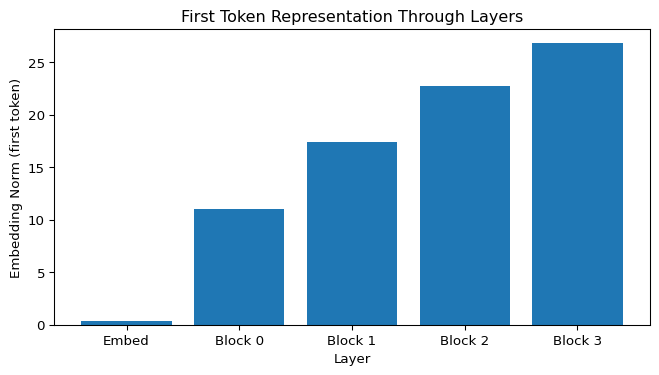

In [17]:
# See how a single token's representation changes through layers
model = create_gpt_tiny(vocab_size=100)
token_ids = torch.randint(0, 100, (1, 8))

_, hidden = model(token_ids, return_hidden_states=True)

# Track first token through layers
first_token_norms = [h[0, 0].norm().item() for h in hidden]

plt.figure(figsize=(8, 4))
plt.bar(range(len(first_token_norms)), first_token_norms)
plt.xlabel('Layer')
plt.ylabel('Embedding Norm (first token)')
plt.title('First Token Representation Through Layers')
plt.xticks(range(len(first_token_norms)), ['Embed'] + [f'Block {i}' for i in range(len(model.blocks))])
plt.show()

## Summary

Key takeaways:

1.  **Transformer architecture**: Input embeddings -\> N transformer
    blocks -\> Final LayerNorm -\> Output projection

2.  **Each block has two sublayers**:

    -   Multi-head attention (tokens communicate)
    -   Feed-forward network (tokens processed independently)

3.  **Pre-Norm architecture**: LayerNorm before each sublayer, with a
    “clean” residual path for stable gradients

4.  **Layer normalization**: Normalizes across the embedding dimension,
    keeping activations in a stable range

5.  **Residual connections**: `x + f(x)` enables gradient flow through
    very deep networks (100+ layers)

6.  **Feed-forward networks**: 4x expansion with GELU activation
    provides computational capacity

7.  **Weight tying**: Sharing token embedding and output projection
    reduces parameters and improves performance

8.  **Initialization matters**: Small initial weights (std=0.02) prevent
    exploding activations

9.  **Parameter scaling**: Total params $\approx V \times d + 12Nd^2$
    (dominated by FFN for large models)

10. **Architectural variations**: Modern LLMs (LLaMA, Mistral) use
    RMSNorm, RoPE, and SwiGLU for better efficiency

## What’s Next

In [Module 07: Training](../m07_training/lesson.qmd), we’ll train our
transformer on actual data using cross-entropy loss, learning rate
scheduling, and gradient accumulation.